In [1]:
import numpy as np
import torch
from collections import OrderedDict
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [2]:
transform = transforms.Compose([transforms.ToTensor()])

grad_data = np.load('/home/mila/a/ahmedm/Gradient-based-attribution/batch_gradient_deviation_scores.npy')
feldman_raw_data = np.load('cifar100_infl_matrix.npz')
data_path = '/home/mila/a/ahmedm/scratch/'
trainset = torchvision.datasets.CIFAR100(root=data_path, train=True,
                                        download=False, transform=transform)
class_names = trainset.classes

In [3]:
sorted_grad_indices = np.argsort(grad_data)
ordered_rank_dict = OrderedDict((int(idx), grad_data[idx]) for idx in sorted_grad_indices)


top_10_pairs = sorted(ordered_rank_dict.items(), key=lambda item: item[1], reverse=True)[:10]
top_10_indices = [pair[0] for pair in top_10_pairs]
top_10_scores = [pair[1] for pair in top_10_pairs]

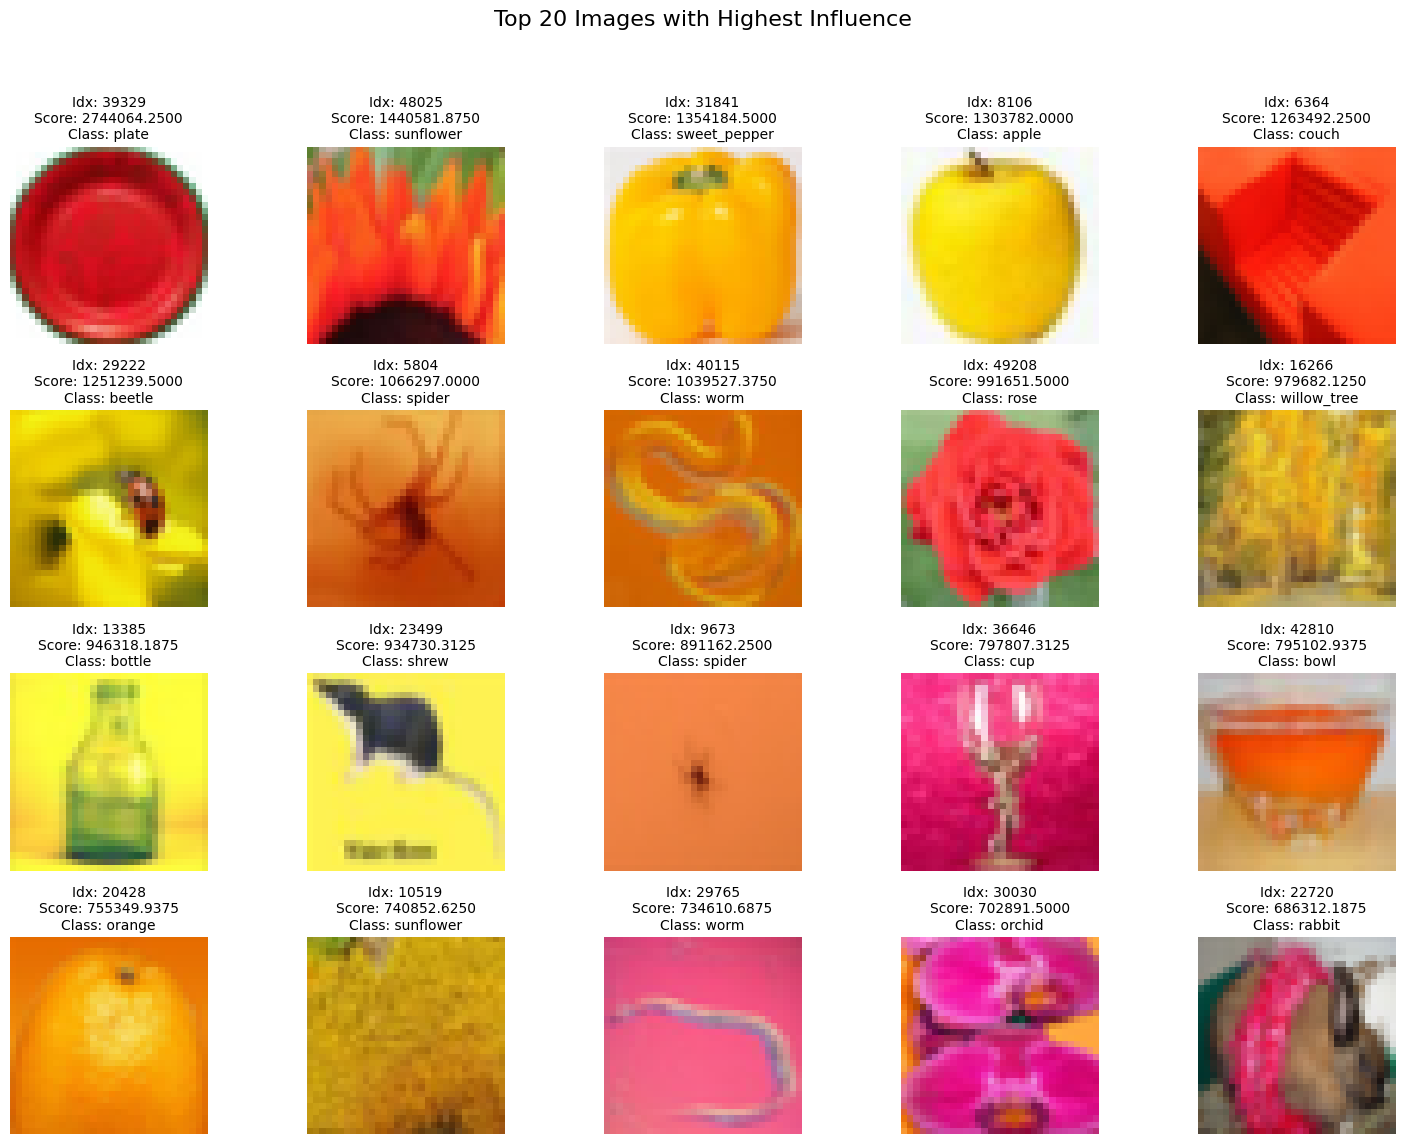

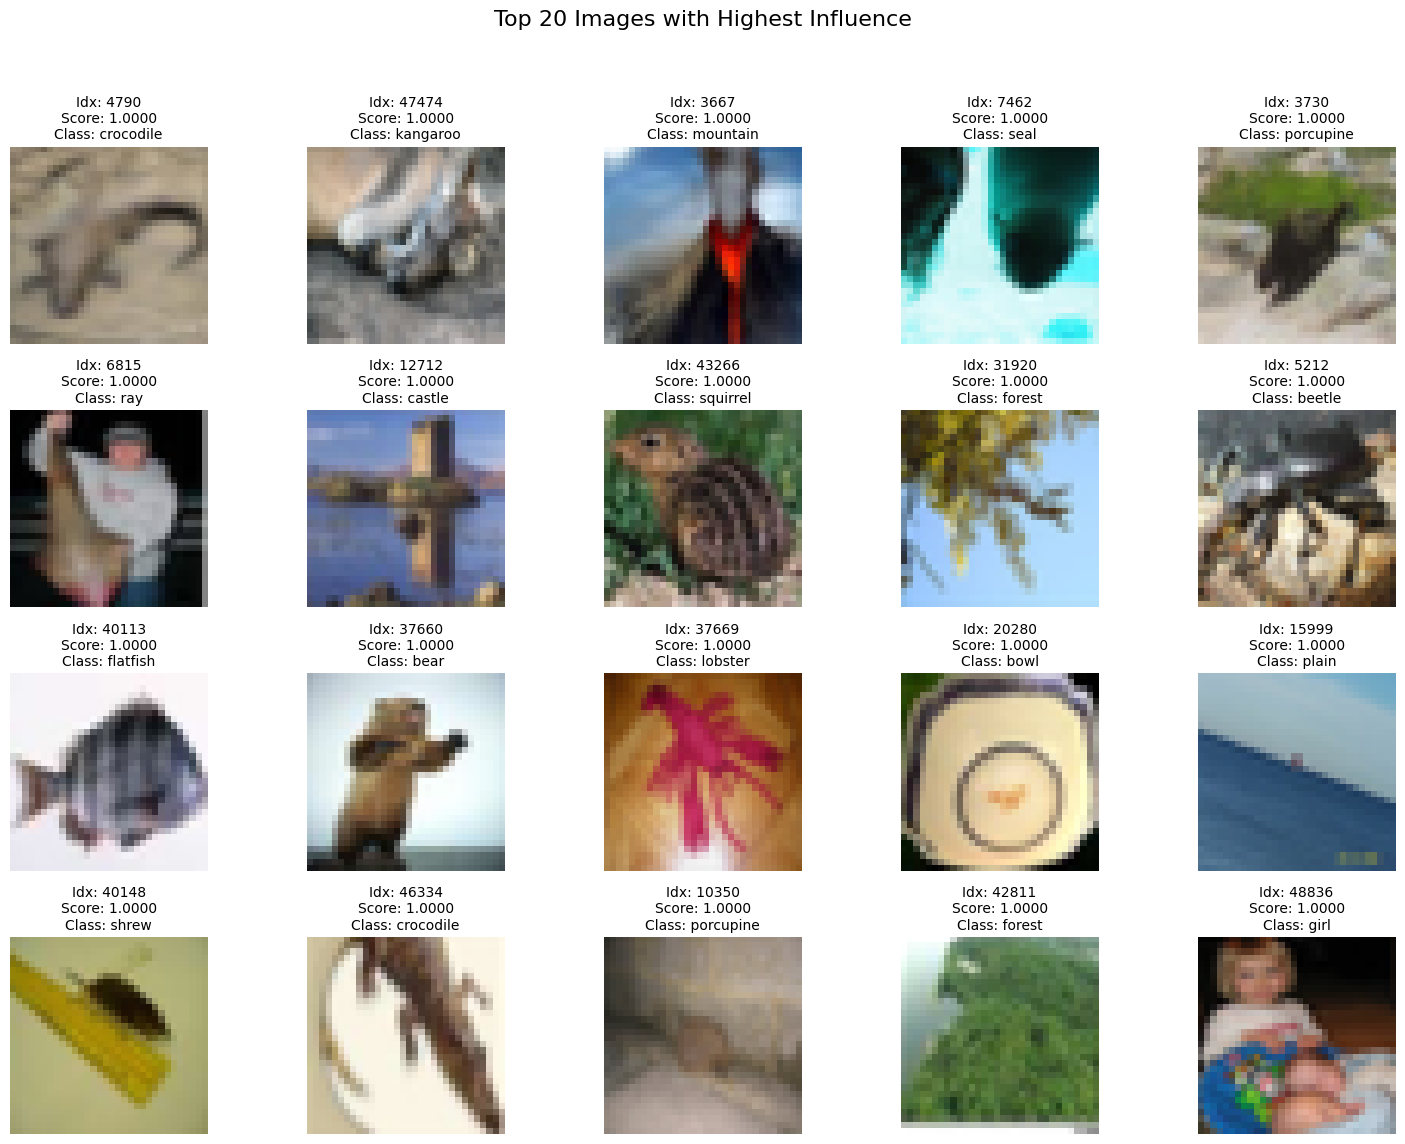

In [ ]:
def imshow(img):
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


def plot_top_scores(arr, up_to=10):
    sorted_indices = np.argsort(arr)[::-1][:up_to]
    top_scores = arr[sorted_indices]
    cols = 5
    rows = (up_to + cols - 1) // cols  # Ceiling division
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows))
    fig.suptitle(f'Top {up_to} Images with Highest Influence', fontsize=16)
    axes_flat = axes.flatten()

    for i in range(up_to):
        idx = int(sorted_indices[i])
        image, label = trainset[idx]
        class_name = class_names[label]
        
        ax = axes_flat[i]
        ax.imshow(image.permute(1, 2, 0))
        ax.set_title(f"Idx: {idx}\nScore: {top_scores[i]:.4f}\nClass: {class_name}", fontsize=10)
        ax.axis('off')
    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

up_to = 20
plot_top_scores(grad_data, up_to)
plot_top_scores(feldman_raw_data['tr_mem'], up_to)

In [13]:
from scipy.stats import pearsonr
def sorted_pearson_correlation(arr1, arr2):
    a = np.array(arr1)
    b = np.array(arr2)
    corr, pval = pearsonr(a, b)
    return corr,pval

In [ ]:
pearson_score,p_val = sorted_pearson_correlation(grad_data,feldman_raw_data['tr_mem'])
print(f'Pearson correlation and p value between Feldmans memorization score and our score {float(pearson_score),float(p_val)}')

Pearson correlation and p value between Feldmans memorization score and our score (0.5739297794198266, 0.0)


In [32]:
def get_influence_per_example(data, agg_method='max'):
    """
    Computes aggregated influence for each training example.
    
    Args:
        file_path: Path to the .npz file.
        agg_method: 'max' to get the highest influence on any test point,
                    'mean' to get the average influence across test points.
    """
    tr_labels = data['tr_labels']
    n_train = len(tr_labels)
    
    # Initialize global array
    results_array = np.zeros(n_train)
    
    # Map the string argument to the corresponding numpy function
    if agg_method == 'max':
        agg_func = np.max
    elif agg_method in ['mean', 'average']:
        agg_func = np.mean
    else:
        # Default to max if something weird is passed, or raise error
        raise ValueError("agg_method must be 'max' or 'mean'")

    # Iterate through classes (assuming keys follow the pattern tr_classidx_{k})
    # Extracting class numbers from the keys themselves
    classes = [int(k.split('_')[-1]) for k in data.keys() if k.startswith('tr_classidx_')]

    for k in classes:
        matrix_key = f'infl_matrix_class{k}'
        idx_key = f'tr_classidx_{k}'
        
        if matrix_key in data:
            infl_matrix = data[matrix_key]
            tr_indices = data[idx_key]
            
            # Apply the chosen aggregation across columns (axis 1)
            # This condenses the (n_train_K, n_test_K) matrix to (n_train_K,)
            aggregated_vals = agg_func(infl_matrix, axis=1)
            
            # Map back to global indices
            results_array[tr_indices] = aggregated_vals
            
    return results_array

# Usage Examples:
# max_infl = get_influence_per_example('data.npz', agg_method='max')
# avg_infl = get_influence_per_example('data.npz', agg_method='mean')

max_influence_arr = get_influence_per_example(feldman_raw_data,'max')
avg_influence_arr = get_influence_per_example(feldman_raw_data,'mean')

In [ ]:
pearson_score,p_val = sorted_pearson_correlation(grad_data,max_influence_arr)
print(f'Pearson correlation and p value between Feldmans max influence on a test point score and our score {float(pearson_score),float(p_val)}')

Pearson correlation and p value between Feldmans memorization score and our score (0.22792698998612382, 0.0)


In [36]:
pearson_score,p_val = sorted_pearson_correlation(grad_data,avg_influence_arr)
print(f'Pearson correlation and p value between Feldmans avg influence on a test point score and our score {float(pearson_score),float(p_val)}')

Pearson correlation and p value between Feldmans avg influence on a test point score and our score (0.11306828498624988, 6.366045798319342e-142)


In [37]:
high_influence_data = np.load('cifar100_high_infl_pairs_infl0.15_mem0.25.npz')


In [41]:
high_influence_data['tr_idx'].shape

(1015,)